# 3 - A Trilha Acadêmica - A.2 Redes neurais convolucionais (CNN)

**Aluna:** Lívia Maria B. Aragão

**Disciplina:** Redes Neurais

**Professor:** Daniel Cassar

## Introdução
As **Redes Neurais Convolucionais (CNN)** são modelos de aprendizado de máquina que conseguem realizar diversas tarefas de mapeamento e classificação de imagens. Utilizando uma arquitetura hierárquica de camadas, as CNNs conseguem performar operações convolucionais, extrair e capturar características espaciais e padrões em imagens em diferentes níveis de abstração. Suas aplicações são diversas: desde as mais "óbvias" (reconhecimento facial, detecção de objetos, classificação de imagens, diagnóstico médico, processamento de linguagem natural) até objetos de estudo científicos, como algumas das realizadas no CNPEM:

- Associadas a microscopia/difração - reconstrução tomográfica, segmentação automática e reconhecimento de padrões (difração);
- Biologia estrutural - predição de estrutura de proteínas, triagem virtual de moléculas, Classificação de imagens de cryo-EM;
- Ciência de Materiais - caracterização de nanomateriais, atestar qualidade de filmes.

O objetivo desse notebook é justamente explorar e explicar um pouco as Redes Neurais Convolucionais, demonstrando problemas que podem ser resolvidos, a lógica matemática, implementação em PyTorch, vantagens e limitações do modelo.

In [1]:
# Importações 
import numpy as np
import pandas as pd 
import cv2
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn 
import torch.optim as optim 
import os
import seaborn as sns

from medmnist import PneumoniaMNIST, DermaMNIST
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchmetrics import MetricCollection, Accuracy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

C:\Users\livia25013\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Um pouco de história...
Em 1962, o estudo neurobiológico de David Hubel e Torsten Wiesel sobre  o córtex visual de gatos (vídeo de um dos experimentos - [https://youtu.be/IOHayh06LJ4?si=SzZw58_ApiXPzveK](https://youtu.be/IOHayh06LJ4?si=SzZw58_ApiXPzveK)) revelou como os neurônios visuais detectam características como orientação e estão organizados de forma hierárquica, descoberta que lhes rendeu o Prêmio Nobel de Fisiologia ou Medicina de 1981. [1]

Inspirado nesses mecanismos e em um modelo já existente (Neocognition), Yann LeCun propõs a primeira rede neural convolucional multicamada, a ConvNet, capaz de resolver problemas como reconhecimento de escritas manuais, mesmo com arquitetura simples. [2] Anos depois, esse modelo foi aprimorado com mais camadas e técnicas de regularização, firmando as bases das CNNs modernas. 

Vale ressaltar também que, no início dos anos 2000, a criação de grandes bancos de imagens, como a  Mixed National Institute of Standards and Technology (MNIST) database e a ImageNet, impulsionaram a avaliação e a evolução dessas arquiteturas, ampliando seu desempenho, aplicações e popularidade.

## Agora sim! O que são de fato as CNN?
As Redes Neurais Convolucionais (CNN) são arquiteturas de _deep learning_ utilizadas para o processamento de imagens. Por meio da convolução, é possível encontrar _features_ importantes dos dados fornecidos pela aplicação de filtros. Esse é o maior diferencial das CNN: processamento e extração automática de características diretamente das imagens! [2, 3, 4]

As principais camadas dessa arquitetura são: 
- Camadas convolucionais
- Pooling
- Função de Ativação (ReLU)
- Camadas totalmente conectadas

### Camadas convolucionais
Estas são o "coração das CNN". 
Nelas, um operador convolucional 2D é aplicado aos dados de entrada com um conjunto de filtros "aprendíveis" (_kernels_), na forma de pequenas matrizes. Estes permitem analisar diversas regiões das imagens, gerando produtos que representam a combinação dos pesos um determinado filtro aprendido e a região correspondente. Assim, o _output_ dessa camada é um mapa de características que permite capturar/extrair padrões importantes, como bordas, texturas e formas.

Então, o operador convolucional é uma função matemática utilizada para combinar dois sinais ou funções a fim de produzir um terceiro sinal que representa a influência de um sinal sobre o outro, ponderada pela forma do outro sinal. Sua fórmula é dada por [2]:

$$
S(i, j) = (I \times K)(i, j) = \sum_m \sum_n I(i+m, j+n)K(m, n)
$$

Tal que: 

$S(i, j)$ - valor no mapa de características para a posição (i, j);

$I$ - imagem de entrada; 

$K$ - kernel; 

$m/n$ - índices que percorrem as dimensões do filtro.

Nesse caso, o operador descrito era 2D, ideal para análise de imagens (maioria dos casos). No entanto, também existem operadores 1D e 3D. Para eles, a lógica do operador é a mesma, o que muda é a dimensão varrida. O caso 1D é ideal para usar em séries/sinais, e o 3d, volumes, vídeos.

O tamanho e a resolução da saída final, ou seja, do mapa de características dessa operação dependem alguns fatores. Sua fórmula é dada por:
$$
S = \Big\lfloor \frac{W - F + 2P}{S} \Big\rfloor +1
$$

Onde: 
$W$ - tamanho da imagem;

$F$ - tamanho do filtro;

$P$ - tamanho do _padding_ - processo de adicionar linhas e colunas extras de zeros ao redor da imagem de entrada antes de aplicar os filtros, podendo ajudar a preservar as dimensões espaciais da imagem à medida que ela passa pelas camadas convolucionais;

$S$ - _stride_ - "salto", corresponde à distância entre posições de filtro adjacentes, quanto maior, menor a resolução.

Vejamos a mudança de dimensões após o passo convolucional aplicado em diferentes dimensões.

In [2]:
conv1d = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
sinal = torch.randn(1, 1, 100)  
saida1d = conv1d(sinal)
print(f"1D -> Entrada: {sinal.shape} → Saída: {saida1d.shape}")

conv2d = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
imagem = torch.randn(1, 3, 32, 32)  
saida2d = conv2d(imagem)
print(f"2D -> Entrada: {imagem.shape} → Saída: {saida2d.shape}")

conv3d = nn.Conv3d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
volume = torch.randn(1, 1, 16, 32, 32)  
saida3d = conv3d(volume)
print(f"3D -> Entrada: {volume.shape} → Saída: {saida3d.shape}")

1D -> Entrada: torch.Size([1, 1, 100]) → Saída: torch.Size([1, 4, 100])
2D -> Entrada: torch.Size([1, 3, 32, 32]) → Saída: torch.Size([1, 16, 32, 32])
3D -> Entrada: torch.Size([1, 1, 16, 32, 32]) → Saída: torch.Size([1, 8, 16, 32, 32])


As camadas convolucionais receberam quatro parâmetros: númeor de canais de entrada e de saída, tamanho do kernel e quantidade de linhas adicionadas no _padding_. Além disso, foram criados objeto de diferentes dimensões, `(num_lote, num_canais, quantidade de dados/pixels/profundidade e pixels)`. Veja que a quantidade de saídas muda, mas as dimensões dos dados são mantidas.

### Pooling 
Camada de redução dimensional dos mapas de características produzidos nas camadas convolucionais. O critério do filtro bidimensional realizado depende do problema, sendo o _maxpooling_ (maior valor de _kernel_) e o _averagepooling_ (valor médio de _kernel_) os mais utilizados. Dessa maneira, é feita uma sumarização de regiões da imagem, retendo informações mais relevantes. [2, 3, 4]

Outra vantagem dessa camada é a redução do _overfitting_. Como o número de parâmetros e a complexidade computacional diminui, o pooling obriga a rede a se concentrar nas características essenciais, reduzindo assim sua capacidade de “memorizar” ruídos específicos ou posições exatas nos dados de treinamento.

### Função de ativação - ReLU
As funções de ativação introduzem não-linearidade ao modelo, ajudando a aprender com maior complexidade, capacidade de abstração e assertividade. Sua escolha impacta na performance e na convergência do modelo escolhido, possuindo diferentes funções mais apropriadas para resolverem diferentes problemas. 

A ReLU, em específico, é uma função simples e efetiva em reduzir o problema do gradiente nulo durante o treinamento. Sua fórmula é dada por:

$$
f(x) = max (0, x)
$$

em que x é a entrada do neurônio.

### Camadas totalmente conectadas ou densas
Camada final, conecta todos os neurônios anteriores, e com a _features_ extraidas, selecionadas, filtradas e aprendidas pelas camadas convolucionais e _pooling_ realiza a previsão do modelo.

Essa estrutura é a base das CNNs. Outras estratégias podem ser aplicadas em conjunto para tratar melhor de problemas propostos. Agora, conhecendo a arquitetura geral, tentemos implementar uma CNN utilizando o PyTorch.


**OBS: "A Maldição da Dimensionalidade"** - As dimensões dos tensores representativos das imagens mudam por diversas vezes durante a CNN. Existe uma lógica nessas variações, convolucionais geralmente mantém ou reduz (depende do _padding_) as dimensões e aumentas os "canais" (profundidade), _pooling_ diminui as dimensões, mantendo os canais e as lineares colapsam tudo em um 1 vetor. [2]

## Implementação com PyTorch
## _Dataset - DermaMNIST_
`DermaMNIST` é um dataset de imagens dermatoscópicas, de uma biblioteca de datasets de imagens médicas, o MedMNIST. O nome, MNIST, deriva do famoso dataset homônimo de LeCun (mencionado acima), Modified National Institute of Standards and Technology, amplamente utilizado para treinar e testar modelos _deep learning_ de aprendizado de máquina e visão computacional. Tal construção, então, faz analogia a esse ser um banco de dados que também é uma base forte, nesse caso, para imagens médicas. [5]

As 10.015 imagens do `DermaMNSIT` apresentam lesões cutâneas pigmentadas coletadas de pacientes em dois centros de estudo na Austrália e na Áustria, com seus diagnósticos confirmados por histopatologia, microscopia confocal, consultas de acompanhamento clínico ou consenso de especialistas. São 95% das lesões encontradas na prática clínica, subdividas em sete categorias de doenças no conjunto de dados, sendo um problema multiclasse. [6]

Aqui, trabalharemos comparando o uso de duas arquiteturas, uma bem simples e outra mais complexa, para tentar resolver esse problema. Ao final, faremos uma análise comparativa dos desempenhos dos modelos.

## 1. Arquitetura Simples

### Carregamento e pré-processamento dos dados
As CNNs esperam trabalhar com tensores que indiquem os "canais" (escalas de cores, _greyscale_ ou RGB) e as dimensões das imagens. Então, antes de qualquer passo, é necessário converter as imagens a esse formato. [7, 8, 9]

In [3]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
    ])
eval_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
        ])

train_data = DermaMNIST(split="train", 
                        download=True, 
                        transform=train_transform)
val_data = DermaMNIST(split="val", 
                        download=True, 
                        transform=eval_transform)
test_data = DermaMNIST(split="test", 
                        download=True, 
                        transform=eval_transform)

### Dataloaders
Os Data Loaders são responsáveis pelo carregamento e organização dos dados durante o treinamento da rede neural. No PyTorch, eles recebem argumentos que indicam o tamanho de pacotes de imagens (_batch_size_) que o modelo trabalha, a necessidade de embaralhamento (_shuffle_), as aplicações das transformações do pré-processamento e até de estratégias de estratificação. [7, 8, 9]

Antes de fazer o _load_, analisemos a composição dos datasets para avaliar a necessidade de estratégias de balanceamento ou estratificação.

In [4]:
# Análise de Distribuição dos dados
nomes_classes = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

def distribuicao(dataset, nome):
    contagem = Counter()
    for _, label in dataset:
        label_value = label.item()
        contagem[label_value] += 1
    
    print(f"{nome}:")
    print(f" Total de amostras: {len(dataset)}")
    print(f" Número de classes: {len(contagem)}")
    print(f" Distribuição por classe:")

    for classe in sorted(contagem.keys()):
        nome_classe = nomes_classes[classe]
        porcentagem = (contagem[classe] / len(dataset)) * 100
        print(f"    Classe {nome_classe}: {contagem[classe]:5d} imagens ({porcentagem:.1f}%)")
    print()

distribuicao(train_data, "TREINO")
distribuicao(val_data, "VALIDAÇÃO")
distribuicao(test_data, "TESTE")

TREINO:
 Total de amostras: 7007
 Número de classes: 7
 Distribuição por classe:
    Classe akiec:   228 imagens (3.3%)
    Classe bcc:   359 imagens (5.1%)
    Classe bkl:   769 imagens (11.0%)
    Classe df:    80 imagens (1.1%)
    Classe mel:   779 imagens (11.1%)
    Classe nv:  4693 imagens (67.0%)
    Classe vasc:    99 imagens (1.4%)

VALIDAÇÃO:
 Total de amostras: 1003
 Número de classes: 7
 Distribuição por classe:
    Classe akiec:    33 imagens (3.3%)
    Classe bcc:    52 imagens (5.2%)
    Classe bkl:   110 imagens (11.0%)
    Classe df:    12 imagens (1.2%)
    Classe mel:   111 imagens (11.1%)
    Classe nv:   671 imagens (66.9%)
    Classe vasc:    14 imagens (1.4%)

TESTE:
 Total de amostras: 2005
 Número de classes: 7
 Distribuição por classe:
    Classe akiec:    66 imagens (3.3%)
    Classe bcc:   103 imagens (5.1%)
    Classe bkl:   220 imagens (11.0%)
    Classe df:    23 imagens (1.1%)
    Classe mel:   223 imagens (11.1%)
    Classe nv:  1341 imagens (66.9%)
  

As etapas de treino e validação, principalmente, estão bem desbalanceadas. Prova disso, está na análise da classe nv, prevalecendo em todos os casos, e das classes vasc ou df, sempre muito baixa. Caso o modelo seja treinado dessa forma, o aprendizado pode ser prejudicado por vício ou falta de informações. É preciso uma estratégia para evitar problemas de _overfitting_, por exemplo, para ser aplicada ao Dataloader.

Nesse caso, será aplicado um balanceamento de classes com o `WeightedRandomSampler` [10], operador de PyTorch que permite definir pesos de cada amostra, como o inverso da porcentagem nos datasets não balanceados, para dar mais importância a dados de menor expressividade.

In [5]:
# Estratégia de balanceamento
classes = [label.item() for _, label in train_data]
num_classes = Counter(classes)
pesos = [1.0/num_classes[t] for t in classes]
sampler = WeightedRandomSampler(
    pesos, 
    num_samples=len(pesos), 
    replacement=True)

train_loader = DataLoader(train_data, batch_size=64, sampler = sampler)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

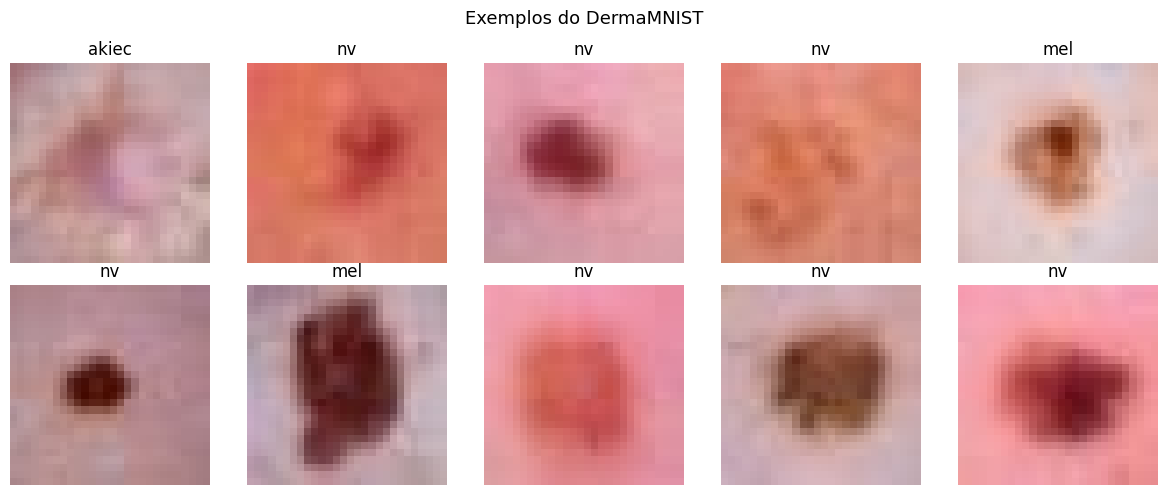

In [6]:
# Visualização das imagens
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
nomes_classes = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(nomes_classes[label.item()])
    ax.axis("off")

plt.suptitle("Exemplos do DermaMNIST", fontsize=13)
plt.tight_layout()
plt.show()

Vale ressaltar que, por fins de simplificação, as imagens do dataset vem redimensionadas para 28×28, o que é uma faca de dois gumes. Tanto facilita o processamento, mas pode perder padrões importantes e, por consequência, eficiência do modelo.

### Modelo CNN (Simples)
Esse problema não é tão complexo. Logo, podemos testar uma arquitetura simples, convolução, ativação, pooling e camada densa para resolvê-lo. 

In [7]:
# Classe do modelo
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 14 * 14, 64)
        self.fc2 = nn.Linear(64, 7)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [8]:
# Instância do modelo
model = CNN1()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Treino/Validação

In [ ]:
# Treino/validação do modelo
melhor_val_loss = float('inf') ## posterior, para resgatar o melhor modelo
historico_loss_treino = []
historico_loss_val = []

for epoch in range(50):
    ##TREINO
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        labels = labels.squeeze().long()
        outputs = model(images)           
        loss = criterion(outputs, labels)
        optimizer.zero_grad()             
        loss.backward()                   
        optimizer.step()                  
        running_loss += loss.item()

    ##VALIDAÇAO
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            labels = labels.squeeze().long()
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()

        avg_val_loss = val_loss / len(val_loader)

    if avg_val_loss < melhor_val_loss:
        melhor_val_loss = avg_val_loss
        torch.save(model.state_dict(), "melhor_modelo1.pth")

    historico_loss_treino.append(running_loss / len(train_loader))
    historico_loss_val.append(avg_val_loss)
        
    if epoch % 10 == 9 or epoch == 0:
        print(f"Época {epoch+1}/50 | "
              f"Loss (treino): {running_loss/len(train_loader):.4f} | "
              f"Loss (validação): {val_loss/len(val_loader):.4f}")

Época 1/50 | Loss (treino): 1.4961 | Loss (validação): 1.2910
Época 10/50 | Loss (treino): 0.5458 | Loss (validação): 1.1356
Época 20/50 | Loss (treino): 0.3781 | Loss (validação): 1.0950


In [ ]:
# Gráficos de perda
plt.figure(figsize=(8, 6))
plt.plot(historico_loss_treino, label="Treino")
plt.plot(historico_loss_val, label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Loss — CNN1")
plt.legend()
plt.show()

### Teste

In [ ]:
# Teste do (melhor) modelo treinado
model = CNN1()
model.load_state_dict(torch.load("melhor_modelo1.pth"))
model.eval()
correct = 0
total = 0

todas_predicoes = []
todos_rotulos = []

with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.squeeze().long() 
        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        predicted = torch.argmax(probabilities, dim=1)

        todas_predicoes.extend(predicted.numpy())
        todos_rotulos.extend(labels.numpy())
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Acurácia no teste: {accuracy:.2f}%")

In [ ]:
# Relatório por classe
nomes_classes = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(classification_report(todos_rotulos, todas_predicoes, target_names=nomes_classes))

#Matriz de confusão
cm = confusion_matrix(todos_rotulos, todas_predicoes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão — CNN1")
plt.show()

O modelo apresentou um desempenho até razoável considerando o multiclasse complexo (7 categorias). Porém, o gráfico das funções de perda revelam que esse valor pode estar mais alto que a realidade. O aumento da perda da validação é um indício de _overfitting_, ou seja, um ajuste excessivo aos dados de treinamento, capturando não apenas os padrões gerais, mas também os ruídos e variações aleatórias, perdendo capacidade de generalização e desempenho que não reflete as capacidades limitadas do modelo. 

A matriz de confusão e o relatório por classe corroboram essa hipótese. O modelo apresenta viés acentuado para a classe majoritária nv, o que infla a acurácia (64%) e mascara o baixo desempenho nas classes minoritárias. O caso mais crítico é o mel (F1 = 0,32), com 85 amostras classificadas incorretamente como nv, falsos negativos. 

As razões podem ser diversas, com destaque para a construção do modelo e o balanceamento dos dados, que não ter sido compensado. Nessa fase inicial, vamos assumir que se deve a simplicidade da arquitetura, não culpemos os dados logo de cara! Vejamos o desempenho do próximo modelo para avaliar se utilizando uma arquitetura mais complexa obtemos um melhor desempenho real, sem sobrestimativas.

## 2. Arquitetura mais complexa
Nessa parte, além da construção diferente das camadas, podemos explorar algumas outras estratégias: [2]

**_1. Data augmentation -_** Técnica de aumento da diversidade dos dados, sem coletar novos, apenas por transformações dos dados já existentes. Podem ser transformações da geometria, do espaço de cor, de filtros dos _kernels_ ou por combinação das anteriores. Essa estratégia pode ajudar na generalização e a robustez do modelo, diminuir o _overfitting_ e aumentar o custo-benefício do modelo (maior eficiência, mesmo com menos dados) [10];

**_2. Batch normalization -_** Normalização da saída da camada anterior subtraindo a média e dividindo pelo desvio padrão do lote, pode ajudar a reduzir a variação interna das covariáveis e melhora a convergência da rede;

**_3. Dropout -_** Descarte aleatório de uma porcentagem dos neurônios da
camada anterior durante o treinamento, ajuda a evitar o _overfitting_ e forçando a rede a aprender características mais robustas.

### Carregamento e pré-processamento dos dados

In [ ]:
train_transform2 = transforms.Compose([
    transforms.RandomRotation(10), ###DATA AUGMENTATION
    transforms.RandomHorizontalFlip(), ###DATA AUGMENTATION
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
    ])
eval_transform2 = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
        ])

train_data2 = DermaMNIST(split="train", 
                        download=True, 
                        transform=train_transform2)
val_data2 = DermaMNIST(split="val", 
                        download=True, 
                        transform=eval_transform2)
test_data2 = DermaMNIST(split="test", 
                        download=True, 
                        transform=eval_transform2)

### Dataloaders

In [ ]:
# Proporções dos datasets
distribuicao(train_data2, "TREINO")
distribuicao(val_data2, "VALIDAÇÃO")
distribuicao(test_data2, "TESTE")

In [ ]:
classes = [label.item() for _, label in train_data]
num_classes = Counter(classes)
pesos = [1.0/num_classes[t] for t in classes]
sampler = WeightedRandomSampler(
    pesos, 
    num_samples=len(pesos), 
    replacement=True)

train_loader2 = DataLoader(train_data2, batch_size=64, sampler = sampler)
val_loader2 = DataLoader(val_data2, batch_size=64, shuffle=False)
test_loader2 = DataLoader(test_data2, batch_size=64, shuffle=False)

### Modelo CNN (Arquitetura mais complexa)

In [ ]:
# Classe do modelo
class CNN2(nn.Module):
    def __init__(self):
        super().__init__()
        ##BLOCO 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), ###BATCH NORMALIZATION
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), ###BATCH NORMALIZATION
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25) ###DROPOUT
        )

        ##BLOCO 2
        self.conv2 = nn.Sequential(      
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), ###BATCH NORMALIZATION
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), ###BATCH NORMALIZATION
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25) ###DROPOUT
        )
        
        ##CLASSIFICADOR
        self.fc = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 7)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
# Instância do modelo
model2 = CNN2()
criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)

### Treino/Validação

In [ ]:
# Treino/validação do modelo
melhor_val_loss2 = float('inf') ## posterior, para resgatar o melhor modelo

historico_loss_treino2 = []
historico_loss_val2 = []

for epoch in range(50):
    ##TREINO
    model2.train()
    running_loss2 = 0.0
    for images2, labels2 in train_loader2:
        labels2 = labels2.squeeze().long()
        outputs2 = model2(images2)           
        loss2 = criterion2(outputs2, labels2)
        optimizer2.zero_grad()             
        loss2.backward()                   
        optimizer2.step()                  
        running_loss2 += loss2.item()

    ##VALIDAÇAO
    model2.eval()
    val_loss2 = 0.0
    with torch.no_grad():
        for images2, labels2 in val_loader2:
            labels2 = labels2.squeeze().long()
            outputs2 = model2(images2)
            val_loss2 += criterion2(outputs2, labels2).item()

        avg_val_loss2 = val_loss2 / len(val_loader2)

    if avg_val_loss2 < melhor_val_loss2:
        melhor_val_loss2 = avg_val_loss2
        torch.save(model2.state_dict(), "melhor_modelo2.pth")

    historico_loss_treino2.append(running_loss2 / len(train_loader2))
    historico_loss_val2.append(avg_val_loss2)
        
    if epoch % 10 == 9 or epoch == 0:
        print(f"Época {epoch+1}/50 | "
              f"Loss (treino): {running_loss2/len(train_loader2):.4f} | "
              f"Loss (validação): {val_loss2/len(val_loader2):.4f}")

In [ ]:
# Gráficos de perda
plt.figure(figsize=(8, 6))
plt.plot(historico_loss_treino2, label="Treino")
plt.plot(historico_loss_val2, label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Loss — CNN2")
plt.legend()
plt.show()

### Teste

In [ ]:
model2 = CNN2()
model2.load_state_dict(torch.load("melhor_modelo2.pth"))
model2.eval()
correct2 = 0
total2 = 0

todas_predicoes2 = []
todos_rotulos2 = []

with torch.no_grad():
    for images2, labels2 in test_loader2:
        labels2 = labels2.squeeze().long() 
        outputs2 = model2(images2)

        probabilities2 = torch.softmax(outputs2, dim=1)
        predicted2 = torch.argmax(probabilities2, dim=1)

        todas_predicoes2.extend(predicted2.numpy())
        todos_rotulos2.extend(labels2.numpy())
        
        total2 += labels2.size(0)
        correct2 += (predicted2 == labels2).sum().item()
accuracy2 = 100 * correct2 / total2
print(f"Acurácia no teste: {accuracy2:.2f}%")

In [ ]:
# Relatório por classe
nomes_classes = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(classification_report(todos_rotulos2, todas_predicoes2, target_names=nomes_classes))

#Matriz de confusão
cm2 = confusion_matrix(todos_rotulos2, todas_predicoes2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues",
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão — CNN2")
plt.show()

O segundo modelo já traz um melhor cenário. Apesar da diminuição da acurácia, dados sobre o modelo que antes pareciam muito problemáticos, como a curva de perda da validação, estão mais adequados. Sobre essa curva, mesmo que tenha um aspecto "ruidoso", apenas um reflexo do uso da estratégia de _Dropout_, não apresenta de forma tão forte aquele aumento extremo, característico do _overfitting_. No entanto, esse padrão sem queda acentuada preocupa sobre o treinamento em mais épocas, devendo tomar cuidado ao realizar mais ciclos treinamento-validação.

Além disso, o segundo modelo apresentou melhora nas classes minoritárias, com destaque para vasc (F1 0,70) e mel (F1 0,42), oq ue refletiu no modelo como um todo (F1 macro subiu para 0,51). Porém, o viés para nv persiste, 272 melanomas ainda foram classificados como nv, piorando em relação ao CNN1. Nessa análise, a leve queda da acurácia está explicada por um _trade-off_, houve aumento da sensibilidade nas classes pequenas aliada a perda de especificidade na classe dominante. 

Portanto, nos dois datasets trabalhados, atingiu-se um desempenho considerável (> 60%). Porém, comparando as funções de perda, métrica de quantificação do erro entre previsões e a realidade, etapas de treino e de validação, há indícios _overfitting_. As matrizes de confusão reforçam as suspeitas. Isso demonstra como a construção da arquitetura deve sempre considerar a quantidade, a resolução e a complexidade dos dados trabalhados e dos problemas propostos. Não necessariamente o segundo modelo proposto é o melhor para a tarefa proposta, mas já se apresenta mais útil e robusto que o anterior, pelo simples aumento do número de camadas e a implementação de outras estratégias vantajosas. Continuar modificando e complexificando a rede pode ser uma boa solução. Vale ressaltar que, existe um limite para tal, uma rede muito complexa também é prejudicial.

**OBS: ResNet**

Problemas muito complexos... exigem arquiteturas à altura! Nesse caso, criar na mão nem sempre é a melhor solução. Existem redes, com estruturas e características particulares, já reconhecidas por resolver tarefas complexas de determinados tipos. A título de ilustração, a ResNet é uma arquitetura de CNN que utiliza do conceito de conexões residuais para resolver o problema do desaparecimento de gradientes em redes profundas, utilizando múltiplos blocos residuais, "aprendendo" o resíduo e, assim, permitindo o gradiente fluir livremente. [2] Isso permite redes com muitas camadas, sem degradação. Para o problema `DermaMNIST`, uma ResNet-18 (224x224) alcança 92% de acurácia (segundo a própria MedMNIST) [5]. Projetos como os realizados no CNPEM, envolvendo reconstrução tomográfica, segmentação de imagens de microscopia, classificação de cryo-EM, também precisam dessa complexidade para convergirem e serem resolvidos.

## Conclusão
Dessa forma, foi possível concluir que realmente as CNNs são redes neurais que conseguem trabalhar bem com imagens, não importando a natureza que elas possuam, basta adequar/refinar a arquitetura para se adequar melhor a estrutura dos dados de entrada. Estas permitem a extração automática das características/_features_ das imagens, garantindo um reconhecimento de padrões com maior assertividade e menor especificidade. Além disso, estratégias adicionais, como a _data augmentation_ e o _dropout_, garantem que resíduos ou ruídos nas imagens sejam compensados/trabalhados, sendo mais amplamente aplicáveis. 

Quanto maior a complexidade das imagens trabalhadas, mais camadas convolucionais, funções de ativação, _pooling_, camadas densas serão necessárias para criar um modelo que realmente consiga realizar a tarefa desejada com robustez. Disso, surgem algumas das limitações das CNNs: um alto custo computacional dependendo do problema e tendências de _overfitting_ (estruturas complexas demais, para problemas "simples"). A limitação por _grid_ e a falta de total compreensão dos processamentos das imagens (questões _"black-box"_) também podem ser pontos negativos.

O desenvolvimento neste _notebook_, por outro lado, demonstrou a _pipeline_ para construir CNNs por meio do PyTorch, evidenciando que pode ser construída praticamente qualquer arquitetura pela junção de camadas desejadas. O PyTorch também permite utilizar arquiteturas já consagradas para a resolução de problemas (desafiadores) clássicos, até mesmo pré-treinados, podendo ser diretamente aplicados a tarefa que desejar.

Portanto, foi possível explorar as CNNs por uma visão teórica, matemática e computacional. O estudo das etapas do modelo e da sua implementação são importantes pois permitem uma compreensão real do modelo, sem estar preso a uma estrutura em específico. O objetivo desse notebook era permitir o leitor ter nível para brincar com redes CNN da maneira que desejar ou precisar. Assim, espero ter conseguido :)

## Referências
1. The Nobel Prize in Physiology or Medicine 1981. Disponível em: [https://www.nobelprize.org/prizes/medicine/1981/press-release/](https://www.nobelprize.org/prizes/medicine/1981/press-release/)
2. KRICHEN, M. Convolutional Neural Networks: A Survey. Computers, v. 12, n. 8, p. 151–151, 28 jul. 2023
3. CONG, S.; ZHOU, Y. A review of convolutional neural network architectures and their optimizations. Artificial Intelligence Review, v. 56, n. 3, 22 jun. 2022
4. GEEKSFORGEEKS. Introduction to Convolution Neural Network. Disponível em: [https://www.geeksforgeeks.org/machine-learning/introduction-convolution-neural-network/](https://www.geeksforgeeks.org/machine-learning/introduction-convolution-neural-network/)
5. MedMNIST. Disponível em: [https://medmnist.com/](https://medmnist.com/)
6. ABHISHEK, K.; JAIN, A.; HAMARNEH, G. Investigating the Quality of DermaMNIST and Fitzpatrick17k Dermatological Image Datasets. Scientific Data, v. 12, n. 1, 1 fev. 2025.
7. LUNA, J. C. PyTorch CNN Tutorial: Build and Train Convolutional Neural Networks in Python. Disponível em: [https://www.datacamp.com/tutorial/pytorch-cnn-tutorial](https://www.datacamp.com/tutorial/pytorch-cnn-tutorial)
8. MELO, C. Introdução ao PyTorch: Como Treinar sua Primeira CNN. Disponível em: [https://sigmoidal.ai/introducao-ao-pytorch-como-treinar-sua-primeira-cnn/](https://sigmoidal.ai/introducao-ao-pytorch-como-treinar-sua-primeira-cnn/). Acesso em: 11 de maio, 2026.
9. OpenGenus/CNN-pytorch: CNN model training and inference in PyTorch. Disponível em: [https://github.com/OpenGenus/CNN-pytorch/tree/main](https://github.com/OpenGenus/CNN-pytorch/tree/main>). Acesso em: 11 de maio, 2026
10. GEEKSFORGEEKS. What is Data Augmentation? How Does Data Augmentation Work for Images? Disponível em: [https://www.geeksforgeeks.org/computer-vision/what-is-data-augmentation-how-does-data-augmentation-work-for-images/](https://www.geeksforgeeks.org/computer-vision/what-is-data-augmentation-how-does-data-augmentation-work-for-images/)